In [2]:
import numpy as np, sys
import matplotlib.pyplot as plt

from numpy.fft import fftn, ifftn, fftfreq

import astropy.units as u
import astropy.constants as cst

# avoid division by zero
eps = sys.float_info.epsilon

## Initial Conditions for a Cosmological N-body Simulation

Before running the simulation, we must specify initial conditions consistent with the early universe:

### 1. Uniform Particle Grid
We distribute particles on a regular 3D cubic grid to represent a nearly homogeneous universe.

### 2. Small Velocity Perturbations
Random Gaussian velocity "kicks" are added to break symmetry and mimic primordial density fluctuations.

> 💡 In more advanced setups, initial displacements would be generated from a cosmological power spectrum using the Zel'dovich approximation or 2LPT.

### 3. Equal Mass Particles
Each particle is assigned the same mass to simplify gravity calculations. In cosmological simulations, this represents dark matter particles.

### Units
Positions are typically in comoving coordinates (e.g., Mpc/h), and velocities are in units consistent with your time integration (e.g., km/s or normalized units).


## Power Spectrum

We generate a simple mock **power-law power spectrum**:

$$ P(k) \propto k^n$$

This spectrum is used to generate a Gaussian random field representing initial density perturbations.


In [3]:
def power_spectrum(k, A=1e4, n=0.9665):
    """
    Generate a simple power-law matter power spectrum: P(k) ~ k^n

    Parameters
    ----------
    k : ndarray
        Wavenumber magnitudes.
    A : float
        Normalization constant.
    n : float
        Spectral index (n=1 for scale-invariant).

    Returns
    -------
    Pk : ndarray
        Power spectrum values.
    """
    Pk = A * (k + eps)**n  
    return Pk

In [26]:
cosmo.meta['n']

0.9665

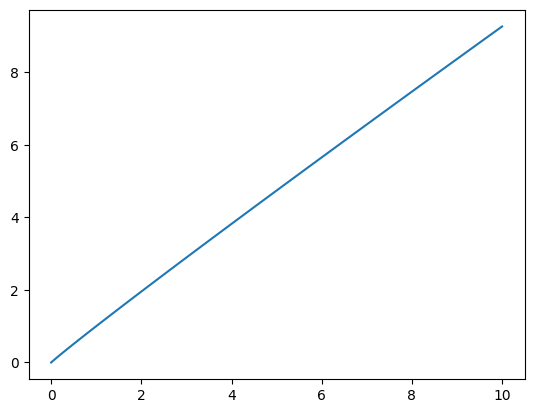

In [4]:
from astropy.cosmology import Planck18 as cosmo

k = np.linspace(0, 10, 100)
pk = power_spectrum(k=k, A=1., n=cosmo.meta['n'])

plt.plot(k, pk)

## Zel'dovich Displacement Field
In the early Universe we assume that there are small density fluctuations, modeled as a **Gaussian random field**. As the density fluctuations approach unity, $\delta \approx 1$, the assumption in the linear evolution of cosmological structure formation break down (non-linear regime) and require a different treatement.

For this reason, [Zel'dovich (1970)](https://articles.adsabs.harvard.edu/pdf/1970A%26A.....5...84Z) developed a solution that instead of considering the Universe as a cosmic fluid, it is represented as a **collection of particles** with **physical trajectory**:

$$ \mathbf{r}(t) = a(t)\left[\mathbf{x} + D(a)\cdot\nabla \phi(\mathbf{x})\right]$$

The first and second term on the right-hand side indicates the displacement respectively due to the cosmic expansion and the scalar gravitational potential.

In ZA, particles move along straight trajectories determined by their **initial displacement vector**, $\mathbf{x}$, and displacements are due to the **gradient of the gravitational potential**, $\nabla\phi(\mathbf{x})$, derived from a power spectrum.



The Zel'dovich Approximation is a great method to generating realistic initial conditions for cosmological simulation. This is due 

To simulate the formation of large-scale structure in the Universe, we use the **Zel'dovich approximation (ZA)**, a technique that approximates early-time particle displacements and velocities based on linear theory.

We compute the displacement field in Fourier space:

$$
\vec{\Psi}(k) \propto i \vec{k} \frac{\delta(k)}{k^2}
$$

Then we transform back to real space using inverse FFTs to obtain displacements.


### Key Ideas:
- The early Universe had small density fluctuations, modeled as a **Gaussian random field**.
- In ZA, particles move along straight trajectories determined by their **initial displacement vector**, scaled by the growth factor.
- Displacements are computed from the **gradient of the gravitational potential**, derived from a power spectrum.

### Steps in the Simplified ZA:
1. Generate a random Gaussian field in Fourier space with a power-law power spectrum.
2. Compute the displacement field ∝ ∇Φ using inverse FFTs.
3. Displace particles from a uniform grid using these vectors.
4. Set initial velocities proportional to the displacement field (via linear theory).

> ⚠️ In production simulations, the power spectrum would come from CAMB/CLASS and velocities would be scaled by the Hubble parameter and growth rate.


In [40]:
def displacement_field(N, box_size, power_spectrum_func):
    """
    Generate 3D Zel'dovich displacement field using a Gaussian random field.

    Parameters
    ----------
    N : int
        Number of particles per dimension.
    box_size : float
        Size of the simulation box (Mpc/h).
    power_spectrum_func : callable
        Function P(k) defining the power spectrum.

    Returns
    -------
    disp_field : ndarray of shape (N, N, N, 3)
        Displacement vectors in real space.
    """
    # Define Fourier space grid
    kx = np.fft.fftfreq(N, d=box_size/N) * 2 * np.pi
    ky = np.fft.fftfreq(N, d=box_size/N) * 2 * np.pi
    kz = np.fft.fftfreq(N, d=box_size/N) * 2 * np.pi
    kx, ky, kz = np.meshgrid(kx, ky, kz, indexing='ij')

    k_squared = kx**2 + ky**2 + kz**2
    k_magnitude = np.sqrt(k_squared)

    # Power spectrum
    Pk = power_spectrum(k_magnitude)

    # Generate Gaussian random complex field with Hermitian symmetry
    noise = np.random.normal(size=(N, N, N)) + 1j * np.random.normal(size=(N, N, N))
    delta_k = noise * np.sqrt(Pk / 2)

    # Compute displacement field in Fourier space: i * k̂ * delta(k) / k
    disp_kx = 1j * kx * delta_k / (k_squared + 1e-10)
    disp_ky = 1j * ky * delta_k / (k_squared + 1e-10)
    disp_kz = 1j * kz * delta_k / (k_squared + 1e-10)

    # Inverse FFT to real space
    disp_x = np.real(np.fft.ifftn(disp_kx))
    disp_y = np.real(np.fft.ifftn(disp_ky))
    disp_z = np.real(np.fft.ifftn(disp_kz))

    # Combine into a displacement field array
    disp_field = np.stack([disp_x, disp_y, disp_z], axis=-1)  # shape (N, N, N, 3)
    
    return disp_field


In [41]:
from scipy.integrate import quad

def integrand(z):
    return (1 + z) / cosmo.efunc(z)**3

def growth_factor(z):
    """Computes linear growth factor D(z), normalized to D(0) = 1."""
    integral, _ = quad(integrand, z, np.inf)
    fz = cosmo.efunc(z) * integral
    f0 = cosmo.efunc(0) * quad(integrand, 0, np.inf)[0]
    return fz / f0

## Apply Displacement to Particle Grid

We create a uniform 3D particle grid and apply the computed Zel'dovich displacements to obtain physical positions and velocities.


In [44]:
# Simulation parameters
Ngrid = 32             # Number of particles per side (N = Ngrid^3)
box_size = 100.0        # Size of the box in Mpc/h
D = growth_factor(z=100)  # Linear growth factor (normalized)

# 1. Generate displacement field
disp_field = displacement_field(Ngrid, box_size, power_spectrum)

# 2. Generate uniform grid of particle positions
lin = np.linspace(0, box_size, Ngrid, endpoint=False)
X, Y, Z = np.meshgrid(lin, lin, lin, indexing='ij')
grid_pos = np.stack([X, Y, Z], axis=-1)  # Shape: (N, N, N, 3)

# 3. Apply displacements
pos = (grid_pos + D * disp_field).reshape(-1, 3)  # Final positions
vel = (D * disp_field).reshape(-1, 3)             # Initial velocities

# Number of particles
N = Ngrid**3

# 4. Equal mass assignment
mass = np.ones((N, 1)) * 1.0 / N

((0.0, 10.0), (0.0, 10.0))

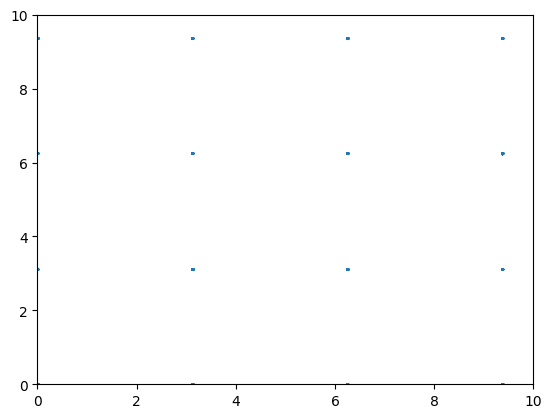

In [45]:
#pos = grid_pos.reshape(-1, 3)
plt.scatter(pos[:,0], pos[:,2], s=1, marker='x')
plt.xlim(0, 10), plt.ylim(0, 10)

## Final Notes

You now have:
- `pos`: Initial positions of particles (N × 3)
- `vel`: Initial velocities (N × 3)
- `mass`: Equal mass for each particle

These initial conditions can be passed to the N-body solver to begin a large-scale structure simulation.

> In realistic simulations, the power spectrum would be computed from a cosmological Boltzmann code (e.g., CAMB or CLASS), and the growth factor `D` would be computed from the cosmology.


Unfortunately, notwithstanding the improvement from linear theory, the approximation fails when particle trajectories cross, as the approach ignores gravitational interaction between particles. Therefore the approximation breaks down as the structure further collapse and overdensity becomes much larger $\delta >> 1$.

The alternative for a complete treatment for later evolution would be to resort to numerical simulations that decompose the matter distribution into collisionless dark matter particles, namely the N-body problem